# Configuración inicial de setup

In [41]:
#using Pkg
#Pkg.add("JuMP")
#Pkg.add("HiGHS")
#Pkg.add("Plots")
#Pkg.add("Colors")

# Setup

In [42]:
using JuMP
using HiGHS
using LinearAlgebra
using Printf
using Plots
using Colors

# Extracción de datos de instancia

In [43]:
instancia = "p02"

r_archivo = "C:/Users/HP/OneDrive - Universidad Autonoma de Coahuila/Escritorio/Maestria CIMA/Semestre2/Optimizacion 2/Tareas/T004-MLP-modeling/MDVRP-Instances-master/dat/$instancia"

datos_archivo = readlines(r_archivo)
datos_limpios = String[]
for i in datos_archivo
     s = strip(i) # quitar espacios
     if !isempty(s) # verificar que no sea un renglon vacio
          push!(datos_limpios, s) # agregar al nuevo arreglo
     end
end
datos_limpios

59-element Vector{String}:
 "2 2 50 4"
 "0 160"
 "0 160"
 "0 160"
 "0 160"
 "1 37 52 0   7 1 4 1 2 4 8"
 "2 49 49 0  30 1 4 1 2 4 8"
 "3 52 64 0  16 1 4 1 2 4 8"
 "4 20 26 0   9 1 4 1 2 4 8"
 "5 40 30 0  21 1 4 1 2 4 8"
 "6 21 47 0  15 1 4 1 2 4 8"
 "7 17 63 0  19 1 4 1 2 4 8"
 "8 31 62 0  23 1 4 1 2 4 8"
 ⋮
 "43  5 64 0  11 1 4 1 2 4 8"
 "44 30 15 0  16 1 4 1 2 4 8"
 "45 39 10 0  10 1 4 1 2 4 8"
 "46 32 39 0   5 1 4 1 2 4 8"
 "47 25 32 0  25 1 4 1 2 4 8"
 "48 25 55 0  17 1 4 1 2 4 8"
 "49 48 28 0  18 1 4 1 2 4 8"
 "50 56 37 0  10 1 4 1 2 4 8"
 "51 20 20 0   0 0 0"
 "52 30 40 0   0 0 0"
 "53 50 30 0   0 0 0"
 "54 60 50 0   0 0 0"

## Recolección de primera linea

La primera línea del archivo contiene:

```
type m n t
```

donde:

- $type$: tipo de problema
- $m$: número de vehículos
- $n$: número de clientes
- $t$: depende del tipo de problema:
     - en PVRP = número de días
     - en MDVRP = número de depósitos
     - en SDVRP = número de tipos de vehículo

**$type$:**

0. (VRP) Problema clásico de rutas de vehículos.
1. (PVRP) Problema periódico de rutas de vehículos.
2. (MDVRP) Problema de rutas de vehículos con múltiples depósitos.
3. (SDVRP) Problema con tipos de vehículo o entregas divididas, según el contexto.
4. (VRPTW) VRP con ventanas de tiempo.
5. (PVRPTW) PVRP con ventanas de tiempo.
6. (MDVRPTW) MDVRP con ventanas de tiempo.
7. (SDVRPTW) Variante SDVRP con ventanas de tiempo

en nuetro caso, trabajaremos con MDVRP por lo que nuestro tipo de problema siempre sera $2$ y $t$ siempre va a representar el numero de depósitos.


In [44]:
primer_linea = split(datos_limpios[1])

p_tipo = parse(Int, primer_linea[1])
m = parse(Int,primer_linea[2])
n = parse(Int,primer_linea[3])
t = parse(Int,primer_linea[4])

@assert p_tipo == 2 "El archivo no es de tipo MDVRP (type != 2)"

In [45]:
# Mostrar info
println("Tipo de problema: ", p_tipo)
println("Vehículos: ", m)
println("Clientes: ", n)
println("Depots: ", t)

Tipo de problema: 2
Vehículos: 2
Clientes: 50
Depots: 4


## Recolección de las capacidades

El formato de cada línea es:

```
D Q
```
donde:

- $D$ = duración máxima permitida de una ruta
- $Q$ = capacidad máxima del vehículo

Como $t$ representa el número de depósitos, entonces habrá una línea por cada depósito con:

- $D$: duración máxima de las rutas asociadas a ese depósito
- $Q$: carga máxima de los vehículos de ese depósito

si en algun momento $D = 0$, quiere decir que no hay algun limite de duración.

In [46]:
lim_depot = []
for i in 2:(1+t)
     part_linea = split(datos_limpios[i])
     D = parse(Int,part_linea[1])
     Q = parse(Int,part_linea[2])
     push!(lim_depot,(D=D,Q=Q))
end
lim_depot

4-element Vector{Any}:
 (D = 0, Q = 160)
 (D = 0, Q = 160)
 (D = 0, Q = 160)
 (D = 0, Q = 160)

In [47]:
capacidades = [dl.Q for dl in lim_depot]
Qs = unique(capacidades)
@assert length(Qs) == 1 "Las capacidades son difieren entre depósitos; adapta el modelo si hace falta."
Q = Qs[1]

160

## Recolección de datos de clientes y depositos

El formato es:

```
i x y d q f a list e l
```

donde:

- i: número o identificador del cliente
- x: coordenada x
- y: coordenada y
- d: duración del servicio en ese cliente
- q: demanda del cliente
- f: frecuencia de visita
- a: número de combinaciones posibles de visita
- list: lista de combinaciones de visita permitidas
- e: inicio de la ventana de tiempo, si existe
- l: fin de la ventana de tiempo, si existe

al nosotros plantear un problema MDVRP, solo se consideran

```
i x y d q
```

In [48]:
clientes = Dict{Int, Dict{Symbol, Any}}()
depositos = Dict{Int, Dict{Symbol, Any}}()

i_inicio = 2 + t
i_final = i_inicio + n + t - 1

@assert i_final <= length(datos_limpios) "Faltan nodos de algun cliente o deposito en el archivo"


In [49]:
ns = datos_limpios[i_inicio:i_final]

for (pos,i) in enumerate(ns)
     part_linea = split(i)
     sep_val = parse.(Float64,part_linea)

     id = Int(sep_val[1])
     x = sep_val[2]
     y = sep_val[3]
     d = sep_val[4]
     q = sep_val[5]

     if pos <= n
          clientes[id] = Dict(
               :x => x,
               :y => y,
               :demanda => q
          )
     else
          depositos[id] = Dict(
               :x => x,
               :y => y,
          )
     end
end


In [50]:
clientes

Dict{Int64, Dict{Symbol, Any}} with 50 entries:
  5  => Dict(:y=>30.0, :demanda=>21.0, :x=>40.0)
  35 => Dict(:y=>63.0, :demanda=>17.0, :x=>62.0)
  30 => Dict(:y=>27.0, :demanda=>19.0, :x=>58.0)
  32 => Dict(:y=>46.0, :demanda=>12.0, :x=>38.0)
  6  => Dict(:y=>47.0, :demanda=>15.0, :x=>21.0)
  45 => Dict(:y=>10.0, :demanda=>10.0, :x=>39.0)
  4  => Dict(:y=>26.0, :demanda=>9.0, :x=>20.0)
  13 => Dict(:y=>25.0, :demanda=>23.0, :x=>5.0)
  12 => Dict(:y=>32.0, :demanda=>29.0, :x=>31.0)
  28 => Dict(:y=>67.0, :demanda=>14.0, :x=>43.0)
  23 => Dict(:y=>57.0, :demanda=>16.0, :x=>16.0)
  41 => Dict(:y=>17.0, :demanda=>27.0, :x=>10.0)
  43 => Dict(:y=>64.0, :demanda=>11.0, :x=>5.0)
  11 => Dict(:y=>41.0, :demanda=>19.0, :x=>42.0)
  36 => Dict(:y=>69.0, :demanda=>6.0, :x=>63.0)
  39 => Dict(:y=>15.0, :demanda=>14.0, :x=>59.0)
  7  => Dict(:y=>63.0, :demanda=>19.0, :x=>17.0)
  25 => Dict(:y=>38.0, :demanda=>28.0, :x=>7.0)
  34 => Dict(:y=>33.0, :demanda=>26.0, :x=>61.0)
  50 => Dict(:y=>37.0, :de

In [51]:
depositos

Dict{Int64, Dict{Symbol, Any}} with 4 entries:
  51 => Dict(:y=>20.0, :x=>20.0)
  54 => Dict(:y=>50.0, :x=>60.0)
  52 => Dict(:y=>40.0, :x=>30.0)
  53 => Dict(:y=>30.0, :x=>50.0)

# Función -> dist_nodos()

Esta funcion calcula la distancia euclidiana entre 2 nodos en un espacio cartesiano de 2D.
La formula es:
$$\sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}$$

In [52]:
function dist_nodos(n1::Tuple{Float64, Float64},n2::Tuple{Float64, Float64})
     return sqrt((n1[1] - n2[1])^2 + (n1[2] - n2[2])^2)
end

dist_nodos (generic function with 1 method)

# Generando matriz de distancias

In [53]:
nodos = Dict{Int,Tuple{Float64,Float64}}()
for (id, posxy) in clientes
     nodos[id] = (posxy[:x],posxy[:y])
end
for (id, posxy) in depositos
     nodos[id] = (posxy[:x],posxy[:y])
end
nodos

Dict{Int64, Tuple{Float64, Float64}} with 54 entries:
  5  => (40.0, 30.0)
  35 => (62.0, 63.0)
  30 => (58.0, 27.0)
  32 => (38.0, 46.0)
  6  => (21.0, 47.0)
  45 => (39.0, 10.0)
  4  => (20.0, 26.0)
  13 => (5.0, 25.0)
  54 => (60.0, 50.0)
  52 => (30.0, 40.0)
  12 => (31.0, 32.0)
  28 => (43.0, 67.0)
  23 => (16.0, 57.0)
  41 => (10.0, 17.0)
  43 => (5.0, 64.0)
  11 => (42.0, 41.0)
  36 => (63.0, 69.0)
  39 => (59.0, 15.0)
  7  => (17.0, 63.0)
  25 => (7.0, 38.0)
  34 => (61.0, 33.0)
  50 => (56.0, 37.0)
  2  => (49.0, 49.0)
  10 => (51.0, 21.0)
  18 => (17.0, 33.0)
  ⋮  => ⋮

In [54]:
distancias = Dict{Tuple{Int,Int}, Float64}()
for i in keys(nodos), j in keys(nodos)
     if i != j
          distancias[(i,j)] = dist_nodos(nodos[i],nodos[j])
     end
end
distancias

Dict{Tuple{Int64, Int64}, Float64} with 2862 entries:
  (41, 10) => 41.1947
  (17, 12) => 9.84886
  (31, 14) => 36.7967
  (19, 16) => 48.0104
  (26, 53) => 44.4185
  (22, 9)  => 26.0
  (27, 26) => 20.2237
  (40, 28) => 71.8679
  (52, 32) => 10.0
  (20, 26) => 31.6228
  (30, 23) => 51.614
  (3, 33)  => 54.3323
  (10, 32) => 28.178
  (15, 19) => 23.1948
  (12, 5)  => 9.21954
  (6, 31)  => 27.2029
  (35, 33) => 55.3624
  (1, 47)  => 23.3238
  (42, 30) => 40.7185
  (21, 34) => 9.05539
  (37, 26) => 46.2709
  (22, 2)  => 10.6301
  (32, 54) => 22.3607
  (41, 52) => 30.4795
  (30, 16) => 15.2315
  ⋮        => ⋮

# Funcion -> graf_int()

In [55]:
function graf_int(cliente,depositos,instancia,label)
     cx = [clientes[i][:x] for i in sort(collect(keys(clientes)))]
     cy = [clientes[i][:y] for i in sort(collect(keys(clientes)))]
     dx = [depositos[i][:x] for i in sort(collect(keys(depositos)))]
     dy = [depositos[i][:y] for i in sort(collect(keys(depositos)))]

     p = scatter(
          cx, cy,
          color = :orange,
          markersize = 5,
          markerstrokewidth = 0,
          label = "Clientes",
          xlabel = "X",
          ylabel = "Y",
          title = "Instancia $instancia $label",
          legend = :topright,
          aspect_ratio = :equal,
          size = (900, 900),
          grid = false,
          framestyle = :none   # cambia a :none si no quieres marco
     )

     scatter!(
          p,
          dx, dy,
          color = :blue,
          markersize = 8,
          markerstrokecolor = :black,
          label = "Depósitos"
     )

     for i in sort(collect(keys(clientes)))
          annotate!(p, clientes[i][:x] + 0.5, clientes[i][:y] + 0.5, text(string(i), 8, :black))
     end
     for d in sort(collect(keys(depositos)))
          annotate!(p, depositos[d][:x] + 0.5, depositos[d][:y] + 0.5, text("D$(d)", 9, :red))
     end

     return p
end

graf_int (generic function with 1 method)

# Visualización de datos

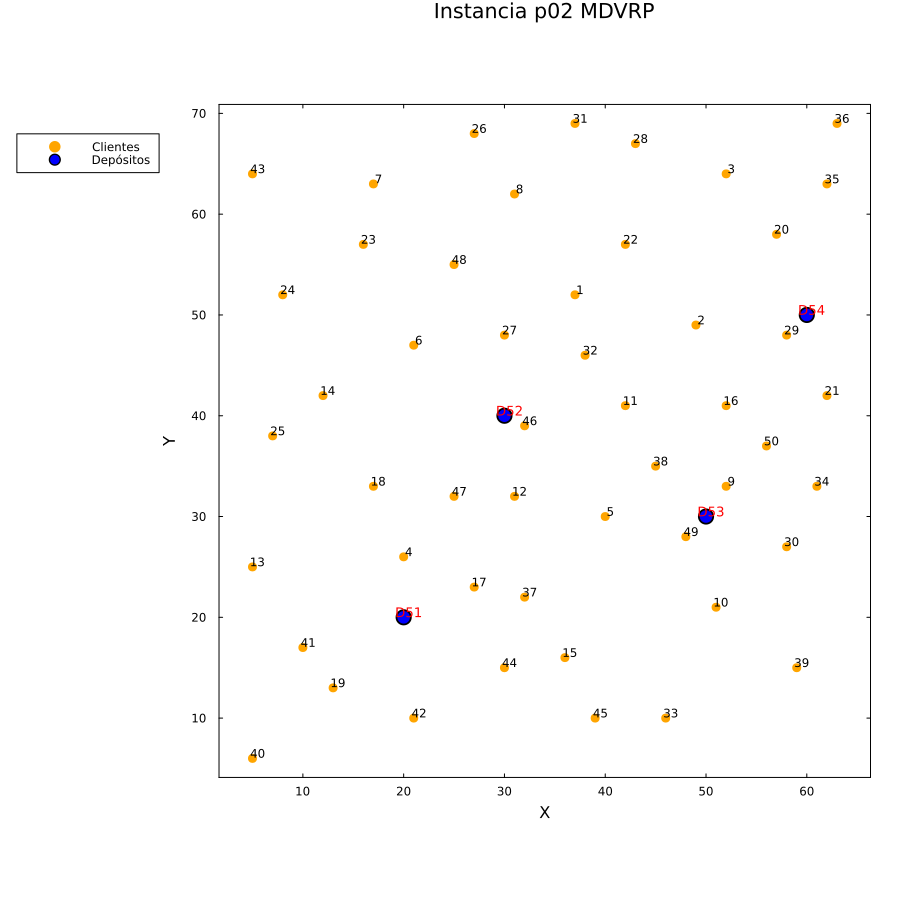

"C:\\Users\\HP\\OneDrive - Universidad Autonoma de Coahuila\\Escritorio\\Maestria CIMA\\Semestre2\\Optimizacion 2\\Tareas\\T004-MLP-modeling\\Resultados\\Graficas_Modelo_Exacto\\Instancia_p02_MDVRP1.png"

In [ ]:
ruta = "C:/Users/HP/OneDrive - Universidad Autonoma de Coahuila/Escritorio/Maestria CIMA/Semestre2/Optimizacion 2/Tareas/T004-MLP-modeling/Resultados/Graficas_Modelo_Exacto"
p = graf_int(clientes,depositos,instancia,"MDVRP")

plot!(
     p,
     framestyle = :box,
     legend = :outertopleft,
     left_margin = -10Plots.mm,
     right_margin = 5Plots.mm,
     top_margin = -10Plots.mm,
     bottom_margin = -10Plots.mm
)

display(p)

ng = "Instancia_$(instancia)_MDVRP"

savefig(p, "$ruta/$ng.png")

# Construcción del modelo matematico exacto

A continuación, se presenta la formulación matemática exacta del MDVRP mediante un modelo de programación entera mixta (MILP).

## Conjuntos

- $D$: conjunto de depósitos, $|D| = t$.
- $N$: conjunto de clientes, $|N| = n$.
- $K = \{1, \dots, m\}$: conjunto de vehículos disponibles por depósito.
- $V = N \cup D$: conjunto de nodos.

In [57]:
D = collect(keys(depositos))     # depósitos
N = collect(keys(clientes))      # clientes
K = 1:m                          # vehículos por depósito
V = union(N, D)

54-element Vector{Int64}:
  5
 35
 30
 32
  6
 45
  4
 13
 12
 28
 23
 41
 43
  ⋮
 22
 47
 14
  3
 33
 40
 48
 15
 51
 54
 52
 53

## Parámetros

- $c_{ij}$: costo o distancia de viajar del nodo $i$ al nodo $j$.
- $q_i$: demanda del cliente $i \in N$.
- $Q$: capacidad máxima de cada vehículo.

In [58]:
demanda = Dict(i => clientes[i][:demanda] for i in N)

Dict{Int64, Float64} with 50 entries:
  5  => 21.0
  35 => 17.0
  30 => 19.0
  32 => 12.0
  6  => 15.0
  45 => 10.0
  4  => 9.0
  13 => 23.0
  12 => 29.0
  28 => 14.0
  23 => 16.0
  41 => 27.0
  43 => 11.0
  11 => 19.0
  36 => 6.0
  39 => 14.0
  7  => 19.0
  25 => 28.0
  34 => 26.0
  50 => 10.0
  2  => 30.0
  10 => 5.0
  18 => 41.0
  26 => 7.0
  27 => 15.0
  ⋮  => ⋮

## Variables de decisión

$$
     x_{ijdk} =
    \begin{cases}
        1 & \text{si el vehículo } k \text{ del depósito } d \text{ viaja de } i \text{ a } j \\
        0 & \text{en otro caso}
    \end{cases}
$$  
$$u_{idk}\text{: carga acumulada del vehículo } k \text{ del depósito } d \text{ al llegar al cliente } i$$


In [59]:
model = Model(HiGHS.Optimizer)

@variable(model, x[i in V, j in V, d in D, k in K], Bin)
@variable(model, u[i in N, d in D, k in K] >= 0)

3-dimensional DenseAxisArray{VariableRef,3,...} with index sets:
    Dimension 1, [5, 35, 30, 32, 6, 45, 4, 13, 12, 28  …  37, 1, 22, 47, 14, 3, 33, 40, 48, 15]
    Dimension 2, [51, 54, 52, 53]
    Dimension 3, 1:2
And data, a 50×4×2 Array{VariableRef, 3}:
[:, :, 1] =
 u[5,51,1]   u[5,54,1]   u[5,52,1]   u[5,53,1]
 u[35,51,1]  u[35,54,1]  u[35,52,1]  u[35,53,1]
 u[30,51,1]  u[30,54,1]  u[30,52,1]  u[30,53,1]
 u[32,51,1]  u[32,54,1]  u[32,52,1]  u[32,53,1]
 u[6,51,1]   u[6,54,1]   u[6,52,1]   u[6,53,1]
 u[45,51,1]  u[45,54,1]  u[45,52,1]  u[45,53,1]
 u[4,51,1]   u[4,54,1]   u[4,52,1]   u[4,53,1]
 u[13,51,1]  u[13,54,1]  u[13,52,1]  u[13,53,1]
 u[12,51,1]  u[12,54,1]  u[12,52,1]  u[12,53,1]
 u[28,51,1]  u[28,54,1]  u[28,52,1]  u[28,53,1]
 u[23,51,1]  u[23,54,1]  u[23,52,1]  u[23,53,1]
 u[41,51,1]  u[41,54,1]  u[41,52,1]  u[41,53,1]
 u[43,51,1]  u[43,54,1]  u[43,52,1]  u[43,53,1]
 ⋮                                   
 u[8,51,1]   u[8,54,1]   u[8,52,1]   u[8,53,1]
 u[17,51,1]  u[17,54,1] 

## Funcion objetivo

$$
\min \sum_{d \in D} \sum_{k \in K} \sum_{i \in V} \sum_{j \in V} c_{ij} \, x_{ijdk}
$$

In [60]:
@objective(model, Min, sum(distancias[(i,j)] * x[i,j,d,k] for d in D, k in K, i in V, j in V if i != j))

39.66106403010388 x[5,35,51,1] + 18.24828759089466 x[5,30,51,1] + 16.1245154965971 x[5,32,51,1] + 25.495097567963924 x[5,6,51,1] + 20.024984394500787 x[5,45,51,1] + 20.396078054371138 x[5,4,51,1] + 35.35533905932738 x[5,13,51,1] + 9.219544457292887 x[5,12,51,1] + 37.12142238654117 x[5,28,51,1] + 36.124783736376884 x[5,23,51,1] + 32.69556544854363 x[5,41,51,1] + 48.79549159502341 x[5,43,51,1] + 11.180339887498949 x[5,11,51,1] + 45.27692569068709 x[5,36,51,1] + 24.20743687382041 x[5,39,51,1] + 40.22437072223753 x[5,7,51,1] + 33.95585369269929 x[5,25,51,1] + 21.213203435596427 x[5,34,51,1] + 17.46424919657298 x[5,50,51,1] + 21.02379604162864 x[5,2,51,1] + 14.212670403551895 x[5,10,51,1] + 23.194827009486403 x[5,18,51,1] + 40.162171256046406 x[5,26,51,1] + 20.591260281974 x[5,27,51,1] + 27.586228448267445 x[5,42,51,1] + 16.278820596099706 x[5,16,51,1] + 32.7566787083184 x[5,20,51,1] + 31.906112267087632 x[5,19,51,1] + 8.246211251235321 x[5,49,51,1] + 18.027756377319946 x[5,44,51,1] + [[...

## Restricciones

### 1. Visita única a cada cliente

Cada cliente debe ser atendido exactamente una vez:
$$
\sum_{d \in D} \sum_{k \in K} \sum_{\substack{j \in V \\ j \neq i}} x_{ijdk} = 1 \quad \forall i \in N
$$

In [61]:
@constraint(model, [i in N], sum(x[i,j,d,k] for d in D, k in K, j in V if j != i) == 1)

1-dimensional DenseAxisArray{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape},1,...} with index sets:
    Dimension 1, [5, 35, 30, 32, 6, 45, 4, 13, 12, 28  …  37, 1, 22, 47, 14, 3, 33, 40, 48, 15]
And data, a 50-element Vector{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}}:
 x[5,35,51,1] + x[5,30,51,1] + x[5,32,51,1] + x[5,6,51,1] + x[5,45,51,1] + x[5,4,51,1] + x[5,13,51,1] + x[5,12,51,1] + x[5,28,51,1] + x[5,23,51,1] + x[5,41,51,1] + x[5,43,51,1] + x[5,11,51,1] + x[5,36,51,1] + x[5,39,51,1] + x[5,7,51,1] + x[5,25,51,1] + x[5,34,51,1] + x[5,50,51,1] + x[5,2,51,1] + x[5,10,51,1] + x[5,18,51,1] + x[5,26,51,1] + x[5,27,51,1] + x[5,42,51,1] + x[5,16,51,1] + x[5,20,51,1] + x[5,19,51,1] + x[5,49,51,1] + x[5,44,51,1] + [[...364 terms omitted...]] + x[5,27,53,2] + x[5,42,53,2] + x[5,16,53,

### 2. Conservación de flujo

Para cada cliente, vehículo y depósito:
$$
\sum_{\substack{j \in V \\ j \neq i}} x_{ijdk} = \sum_{\substack{j \in V \\ j \neq i}} x_{jidk} \quad \forall i \in N, \; d \in D, \; k \in K
$$

In [62]:
@constraint(model, [i in N, d in D, k in K], sum(x[i,j,d,k] for j in V if j != i) == sum(x[j,i,d,k] for j in V if j != i))

3-dimensional DenseAxisArray{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape},3,...} with index sets:
    Dimension 1, [5, 35, 30, 32, 6, 45, 4, 13, 12, 28  …  37, 1, 22, 47, 14, 3, 33, 40, 48, 15]
    Dimension 2, [51, 54, 52, 53]
    Dimension 3, 1:2
And data, a 50×4×2 Array{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}, 3}:
[:, :, 1] =
 -x[35,5,51,1] - x[30,5,51,1] - x[32,5,51,1] - x[6,5,51,1] - x[45,5,51,1] - x[4,5,51,1] - x[13,5,51,1] - x[12,5,51,1] - x[28,5,51,1] - x[23,5,51,1] - x[41,5,51,1] - x[43,5,51,1] - x[11,5,51,1] - x[36,5,51,1] - x[39,5,51,1] - x[7,5,51,1] - x[25,5,51,1] - x[34,5,51,1] - x[50,5,51,1] - x[2,5,51,1] - x[10,5,51,1] - x[18,5,51,1] - x[26,5,51,1] - x[27,5,51,1] - x[42,5,51,1] - x[16,5,51,1] - x[20,5,51,1] - x[19,5,51,1] - x[49,5,51,1] - x[44,5,51,1] - [[..

### 3. Salida y retorno al depósito

Cada vehículo puede salir y regresar a su depósito como máximo una vez:
\begin{align*}
\sum_{j \in N} x_{dj dk} \leq 1 \quad \forall d \in D, \; k \in K \\
\sum_{i \in N} x_{iddk} \leq 1 \quad \forall d \in D, \; k \in K
\end{align*}

In [63]:
@constraint(model, [d in D, k in K], sum(x[d,j,d,k] for j in N) <= 1)

2-dimensional DenseAxisArray{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.LessThan{Float64}}, ScalarShape},2,...} with index sets:
    Dimension 1, [51, 54, 52, 53]
    Dimension 2, 1:2
And data, a 4×2 Matrix{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.LessThan{Float64}}, ScalarShape}}:
 x[51,5,51,1] + x[51,35,51,1] + x[51,30,51,1] + x[51,32,51,1] + x[51,6,51,1] + x[51,45,51,1] + x[51,4,51,1] + x[51,13,51,1] + x[51,12,51,1] + x[51,28,51,1] + x[51,23,51,1] + x[51,41,51,1] + x[51,43,51,1] + x[51,11,51,1] + x[51,36,51,1] + x[51,39,51,1] + x[51,7,51,1] + x[51,25,51,1] + x[51,34,51,1] + x[51,50,51,1] + x[51,2,51,1] + x[51,10,51,1] + x[51,18,51,1] + x[51,26,51,1] + x[51,27,51,1] + x[51,42,51,1] + x[51,16,51,1] + x[51,20,51,1] + x[51,19,51,1] + x[51,49,51,1] + x[51,44,51,1] + x[51,9,51,1] + x[51,31,51,1] + x[51,29,51,1] + x[51,46,51,1] + x[51,21,

In [64]:
@constraint(model, [d in D, k in K], sum(x[i,d,d,k] for i in N) <= 1)

2-dimensional DenseAxisArray{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.LessThan{Float64}}, ScalarShape},2,...} with index sets:
    Dimension 1, [51, 54, 52, 53]
    Dimension 2, 1:2
And data, a 4×2 Matrix{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.LessThan{Float64}}, ScalarShape}}:
 x[5,51,51,1] + x[35,51,51,1] + x[30,51,51,1] + x[32,51,51,1] + x[6,51,51,1] + x[45,51,51,1] + x[4,51,51,1] + x[13,51,51,1] + x[12,51,51,1] + x[28,51,51,1] + x[23,51,51,1] + x[41,51,51,1] + x[43,51,51,1] + x[11,51,51,1] + x[36,51,51,1] + x[39,51,51,1] + x[7,51,51,1] + x[25,51,51,1] + x[34,51,51,1] + x[50,51,51,1] + x[2,51,51,1] + x[10,51,51,1] + x[18,51,51,1] + x[26,51,51,1] + x[27,51,51,1] + x[42,51,51,1] + x[16,51,51,1] + x[20,51,51,1] + x[19,51,51,1] + x[49,51,51,1] + x[44,51,51,1] + x[9,51,51,1] + x[31,51,51,1] + x[29,51,51,1] + x[46,51,51,1] + x[21,51,

### 4. Restricción de capacidad

La demanda total atendida por cada vehículo no debe exceder su capacidad:
$$
\sum_{i \in N}\sum_{\substack{j \in V \\ j \neq i}} q_ix_{ijdk} \leq Q \quad \forall d \in D, \; k \in K
$$

In [65]:
@constraint(model, [d in D, k in K], sum(demanda[i] * sum(x[i,j,d,k] for j in V if j != i) for i in N) <= Q)

2-dimensional DenseAxisArray{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.LessThan{Float64}}, ScalarShape},2,...} with index sets:
    Dimension 1, [51, 54, 52, 53]
    Dimension 2, 1:2
And data, a 4×2 Matrix{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.LessThan{Float64}}, ScalarShape}}:
 17 x[35,5,51,1] + 19 x[30,5,51,1] + 12 x[32,5,51,1] + 15 x[6,5,51,1] + 10 x[45,5,51,1] + 9 x[4,5,51,1] + 23 x[13,5,51,1] + 29 x[12,5,51,1] + 14 x[28,5,51,1] + 16 x[23,5,51,1] + 27 x[41,5,51,1] + 11 x[43,5,51,1] + 19 x[11,5,51,1] + 6 x[36,5,51,1] + 14 x[39,5,51,1] + 19 x[7,5,51,1] + 28 x[25,5,51,1] + 26 x[34,5,51,1] + 10 x[50,5,51,1] + 30 x[2,5,51,1] + 5 x[10,5,51,1] + 41 x[18,5,51,1] + 7 x[26,5,51,1] + 15 x[27,5,51,1] + 13 x[42,5,51,1] + 15 x[16,5,51,1] + 28 x[20,5,51,1] + 9 x[19,5,51,1] + 18 x[49,5,51,1] + 16 x[44,5,51,1] + [[...2590 terms omitted...]] + 

### 5. Restricción de consistencia de depósitos

Se prohíbe que un vehículo asociado a un depósito visite otros depósitos:
\begin{align*}
x_{ijdk} = 0 \quad \forall d \in D, \; k \in K, \; i \in V, \; j \in D, \; j \neq d \\
x_{ijdk} = 0 \quad \forall d \in D, \; k \in K, \; i \in D, \; i \neq d, \; j \in V
\end{align*}

In [66]:
@constraint(model, [d in D, k in K, i in V, j in V; j in D && j != d], x[i,j,d,k] == 0)

JuMP.Containers.SparseAxisArray{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}, 4, NTuple{4, Int64}} with 1296 entries:
  [51, 1, 5, 54 ]  =  x[5,54,51,1] == 0
  [51, 1, 5, 52 ]  =  x[5,52,51,1] == 0
  [51, 1, 5, 53 ]  =  x[5,53,51,1] == 0
  [51, 1, 35, 54]  =  x[35,54,51,1] == 0
  [51, 1, 35, 52]  =  x[35,52,51,1] == 0
  [51, 1, 35, 53]  =  x[35,53,51,1] == 0
  [51, 1, 30, 54]  =  x[30,54,51,1] == 0
  [51, 1, 30, 52]  =  x[30,52,51,1] == 0
  [51, 1, 30, 53]  =  x[30,53,51,1] == 0
  [51, 1, 32, 54]  =  x[32,54,51,1] == 0
  [53, 2, 51, 54]  =  x[51,54,53,2] == 0
                   ⋮
  [53, 2, 51, 52]  =  x[51,52,53,2] == 0
  [53, 2, 54, 51]  =  x[54,51,53,2] == 0
  [53, 2, 54, 54]  =  x[54,54,53,2] == 0
  [53, 2, 54, 52]  =  x[54,52,53,2] == 0
  [53, 2, 52, 51]  =  x[52,51,53,2] == 0
  [53, 2, 52, 54]  =  x[52,54,53,2] == 0
  [53, 2, 52, 52]  =  x[52,52,53,2] == 0
  [53, 2, 53, 51]  =

In [67]:
@constraint(model, [d in D, k in K, i in V, j in V; i in D && i != d], x[i,j,d,k] == 0)

JuMP.Containers.SparseAxisArray{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}, 4, NTuple{4, Int64}} with 1296 entries:
  [51, 1, 54, 5 ]  =  x[54,5,51,1] == 0
  [51, 1, 54, 35]  =  x[54,35,51,1] == 0
  [51, 1, 54, 30]  =  x[54,30,51,1] == 0
  [51, 1, 54, 32]  =  x[54,32,51,1] == 0
  [51, 1, 54, 6 ]  =  x[54,6,51,1] == 0
  [51, 1, 54, 45]  =  x[54,45,51,1] == 0
  [51, 1, 54, 4 ]  =  x[54,4,51,1] == 0
  [51, 1, 54, 13]  =  x[54,13,51,1] == 0
  [51, 1, 54, 12]  =  x[54,12,51,1] == 0
  [51, 1, 54, 28]  =  x[54,28,51,1] == 0
  [53, 2, 52, 47]  =  x[52,47,53,2] == 0
                   ⋮
  [53, 2, 52, 14]  =  x[52,14,53,2] == 0
  [53, 2, 52, 3 ]  =  x[52,3,53,2] == 0
  [53, 2, 52, 33]  =  x[52,33,53,2] == 0
  [53, 2, 52, 40]  =  x[52,40,53,2] == 0
  [53, 2, 52, 48]  =  x[52,48,53,2] == 0
  [53, 2, 52, 15]  =  x[52,15,53,2] == 0
  [53, 2, 52, 51]  =  x[52,51,53,2] == 0
  [53, 2, 52, 54]  = 

### 6. Eliminación de subciclos (MTZ)
$$
q_i \leq u_{idk} \leq Q \quad \forall i \in N, \; d \in D, \; k \in K 
$$
$$
u_{idk} - u_{jdk} + Q \, x_{ijdk} \leq Q - q_j \quad \substack{\forall i, j \in N, \; i \neq j,\\ \; d \in D, \; k \in K}
$$

In [68]:
@constraint(model, [i in N, d in D, k in K], demanda[i] <= u[i,d,k] <= Q)

3-dimensional DenseAxisArray{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.Interval{Float64}}, ScalarShape},3,...} with index sets:
    Dimension 1, [5, 35, 30, 32, 6, 45, 4, 13, 12, 28  …  37, 1, 22, 47, 14, 3, 33, 40, 48, 15]
    Dimension 2, [51, 54, 52, 53]
    Dimension 3, 1:2
And data, a 50×4×2 Array{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.Interval{Float64}}, ScalarShape}, 3}:
[:, :, 1] =
 u[5,51,1] in [21, 160]   u[5,54,1] in [21, 160]   …  u[5,53,1] in [21, 160]
 u[35,51,1] in [17, 160]  u[35,54,1] in [17, 160]     u[35,53,1] in [17, 160]
 u[30,51,1] in [19, 160]  u[30,54,1] in [19, 160]     u[30,53,1] in [19, 160]
 u[32,51,1] in [12, 160]  u[32,54,1] in [12, 160]     u[32,53,1] in [12, 160]
 u[6,51,1] in [15, 160]   u[6,54,1] in [15, 160]      u[6,53,1] in [15, 160]
 u[45,51,1] in [10, 160]  u[45,54,1] in [10, 160]  …  u[45,53,

In [69]:
@constraint(model, [i in N, j in N, d in D, k in K; i != j], u[i,d,k] - u[j,d,k] + Q * x[i,j,d,k] <= Q - demanda[j])

JuMP.Containers.SparseAxisArray{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.LessThan{Float64}}, ScalarShape}, 4, NTuple{4, Int64}} with 19600 entries:
  [5, 35, 51, 1 ]  =  160 x[5,35,51,1] + u[5,51,1] - u[35,51,1] <= 143
  [5, 35, 51, 2 ]  =  160 x[5,35,51,2] + u[5,51,2] - u[35,51,2] <= 143
  [5, 35, 54, 1 ]  =  160 x[5,35,54,1] + u[5,54,1] - u[35,54,1] <= 143
  [5, 35, 54, 2 ]  =  160 x[5,35,54,2] + u[5,54,2] - u[35,54,2] <= 143
  [5, 35, 52, 1 ]  =  160 x[5,35,52,1] + u[5,52,1] - u[35,52,1] <= 143
  [5, 35, 52, 2 ]  =  160 x[5,35,52,2] + u[5,52,2] - u[35,52,2] <= 143
  [5, 35, 53, 1 ]  =  160 x[5,35,53,1] + u[5,53,1] - u[35,53,1] <= 143
  [5, 35, 53, 2 ]  =  160 x[5,35,53,2] + u[5,53,2] - u[35,53,2] <= 143
  [5, 30, 51, 1 ]  =  160 x[5,30,51,1] + u[5,51,1] - u[30,51,1] <= 141
  [5, 30, 51, 2 ]  =  160 x[5,30,51,2] + u[5,51,2] - u[30,51,2] <= 141
  [15, 40, 52, 2]  =  160 x[15,40,52,2] - u[40,52,2] + u[15,52,2

### 7. Eliminación de ciclos triviales
$$
x_{iidk} = 0 \quad \forall i \in V, \; d \in D, \; k \in K
$$

In [70]:
@constraint(model, [i in V, d in D, k in K], x[i,i,d,k] == 0)

3-dimensional DenseAxisArray{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape},3,...} with index sets:
    Dimension 1, [5, 35, 30, 32, 6, 45, 4, 13, 12, 28  …  14, 3, 33, 40, 48, 15, 51, 54, 52, 53]
    Dimension 2, [51, 54, 52, 53]
    Dimension 3, 1:2
And data, a 54×4×2 Array{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}, 3}:
[:, :, 1] =
 x[5,5,51,1] == 0    x[5,5,54,1] == 0    …  x[5,5,53,1] == 0
 x[35,35,51,1] == 0  x[35,35,54,1] == 0     x[35,35,53,1] == 0
 x[30,30,51,1] == 0  x[30,30,54,1] == 0     x[30,30,53,1] == 0
 x[32,32,51,1] == 0  x[32,32,54,1] == 0     x[32,32,53,1] == 0
 x[6,6,51,1] == 0    x[6,6,54,1] == 0       x[6,6,53,1] == 0
 x[45,45,51,1] == 0  x[45,45,54,1] == 0  …  x[45,45,53,1] == 0
 x[4,4,51,1] == 0    x[4,4,54,1] == 0       x[4,4,53,1] == 0
 x[13,13,51,1] =

## Optimización del modelo

In [71]:
# =========================
# OPTIMIZAR
# =========================
time_limit = 300.0
set_silent(model)
set_optimizer_attribute(model, "time_limit", time_limit)
set_optimizer_attribute(model, "mip_rel_gap", 0.1)

tiempo = @elapsed optimize!(model)

# =========================
# RESULTADOS
# =========================

println("\n====================")
println("Status: ", termination_status(model)," ",time_limit)
println("Costo óptimo: ", objective_value(model))
println("====================\n")

if termination_status(model) == MOI.OPTIMAL
     println("Valor óptimo: ", objective_value(model))
else
     println("No se encontró solución óptima.")
end

costo = objective_value(model)


Status: TIME_LIMIT 300.0
Costo óptimo: 1085.7982610577512

No se encontró solución óptima.


1085.7982610577512

## Resultados

In [72]:
ruta_s = "C:/Users/HP/OneDrive - Universidad Autonoma de Coahuila/Escritorio/Maestria CIMA/Semestre2/Optimizacion 2/Tareas/T004-MLP-modeling/Resultados/Datos_Solucion"

open("$ruta_s/Resultados $instancia Solución Exacta MDVRP.txt", "w") do io
     println(io, "====================")
     println(io, "Instancia: ", instancia)
     println(io, "Tiempo total: ", tiempo, " s")
     println(io, "Costo total: ", costo)
end

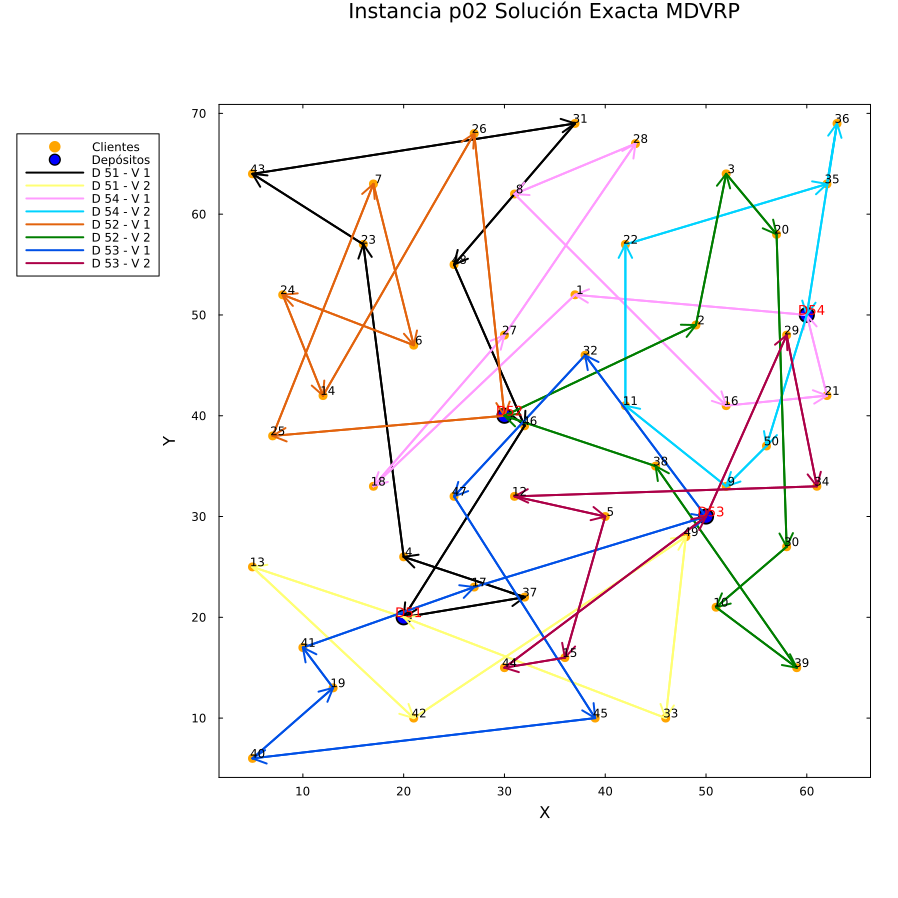

"C:\\Users\\HP\\OneDrive - Universidad Autonoma de Coahuila\\Escritorio\\Maestria CIMA\\Semestre2\\Optimizacion 2\\Tareas\\T004-MLP-modeling\\Resultados\\Graficas_Modelo_Exacto\\Instancia_p02_Solución_Exacta_MDVRP.png"

In [73]:
p = graf_int(clientes, depositos, instancia, "Solución Exacta MDVRP")


# Colores para cada ruta (depósito–vehículo)
colores = distinguishable_colors(length(D) * length(K))

idx = 1

for d in D
     for k in K
     
          arcos = [(i,j) for i in V, j in V if i != j && value(x[i,j,d,k]) > 0.5]
     
          if isempty(arcos)
               continue
          end
     
          primer_arco = true
     
          for (i,j) in arcos
     
               xi, yi = nodos[i]
               xj, yj = nodos[j]
     
               plot!(
                    p,
                    [xi, xj],
                    [yi, yj],
                    lw = 2,
                    color = colores[idx],
                    arrow = :arrow,
                    label = primer_arco ? "D $d - V $k" : false
               )
     
               primer_arco = false
          end
     
          idx += 1
     end
end

plot!(
     p,
     framestyle = :box,
     legend = :outertopleft,
     left_margin = -10Plots.mm,
     right_margin = 5Plots.mm,
     top_margin = -10Plots.mm,
     bottom_margin = -10Plots.mm
)

display(p)

ng = "Instancia_$(instancia)_Solución_Exacta_MDVRP"

savefig(p, "$ruta/$ng.png")

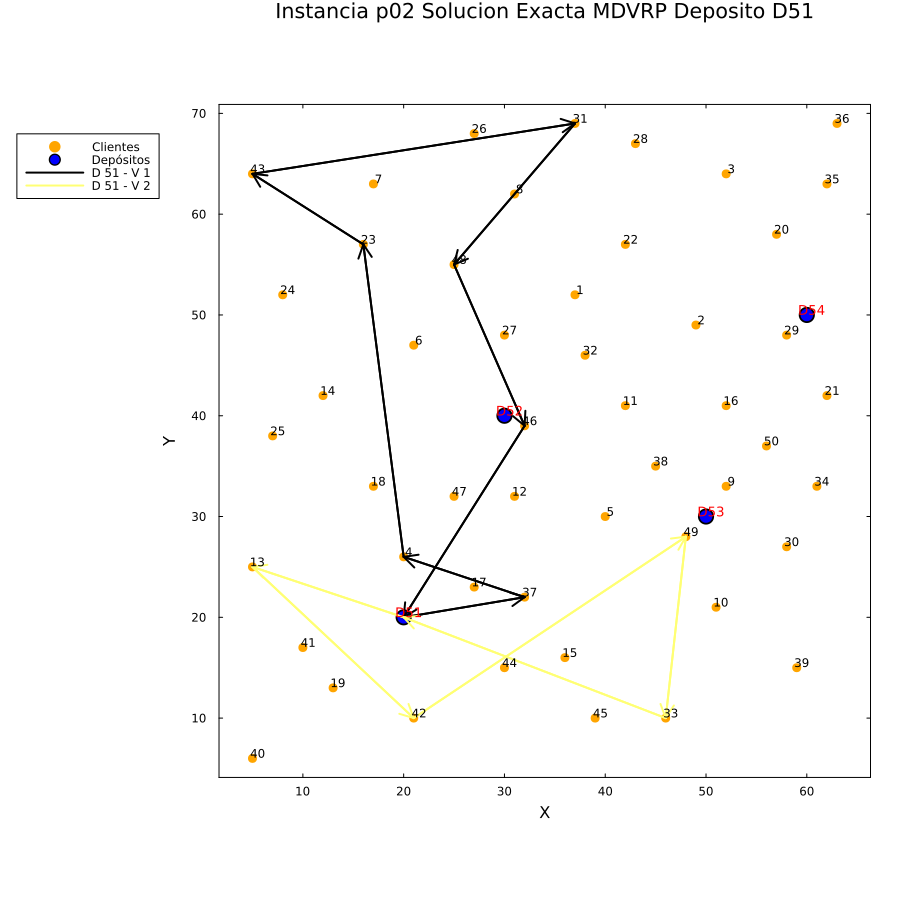

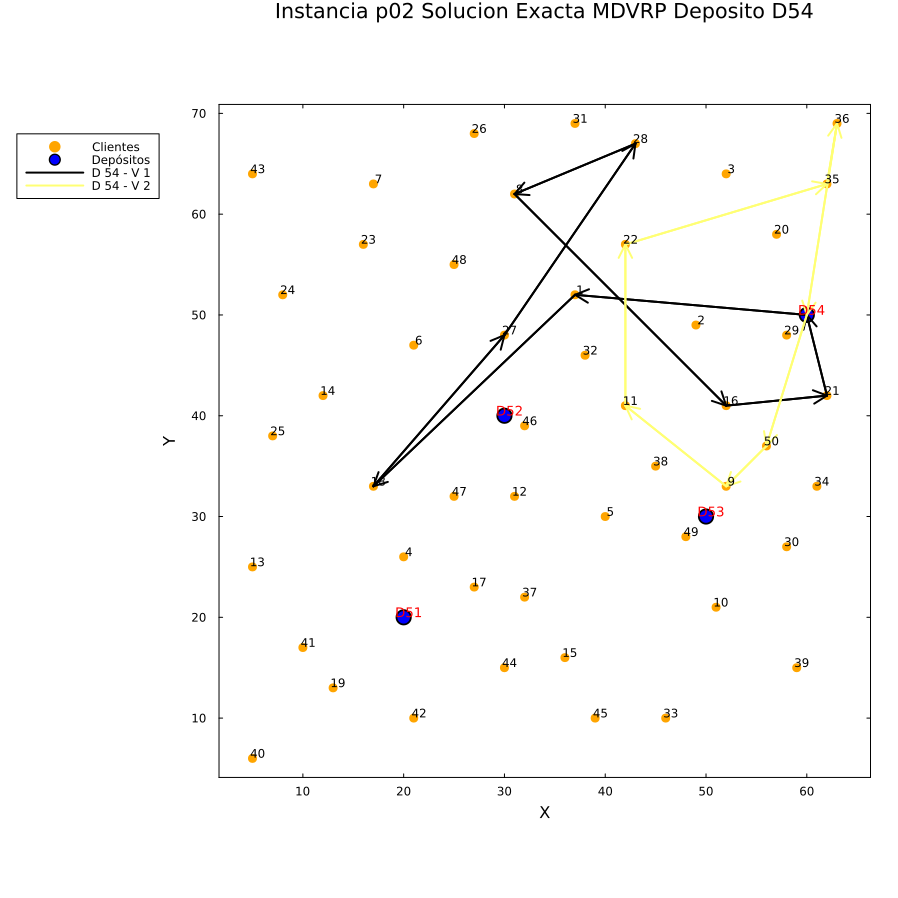

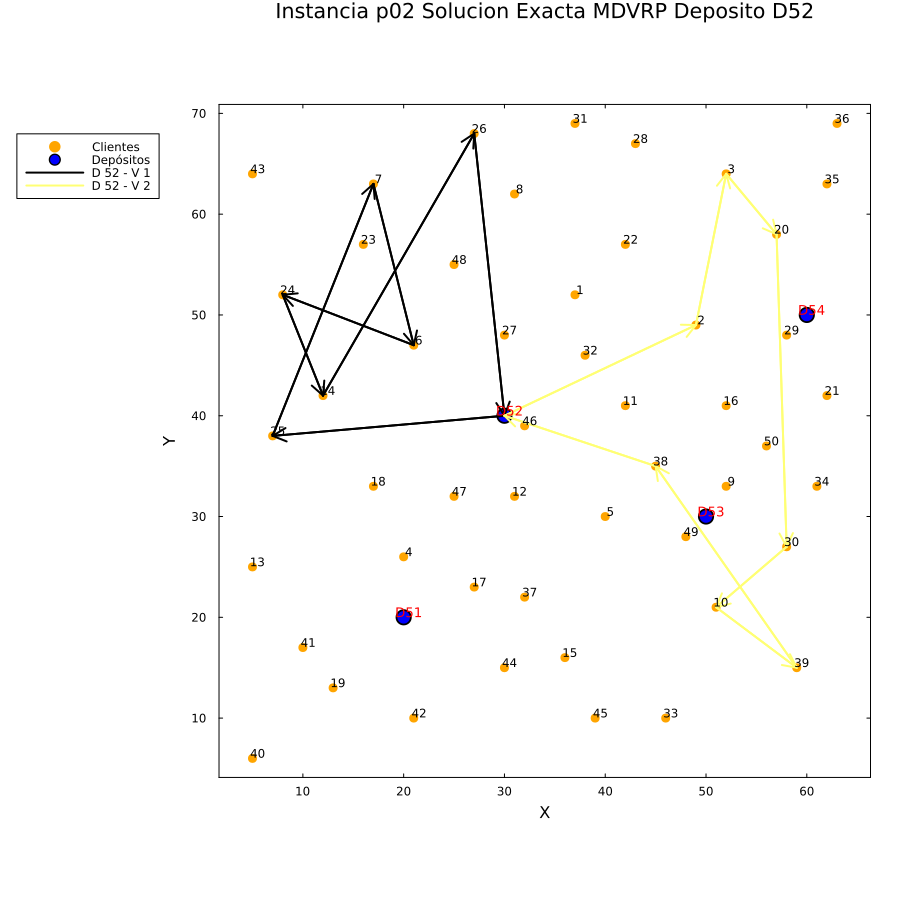

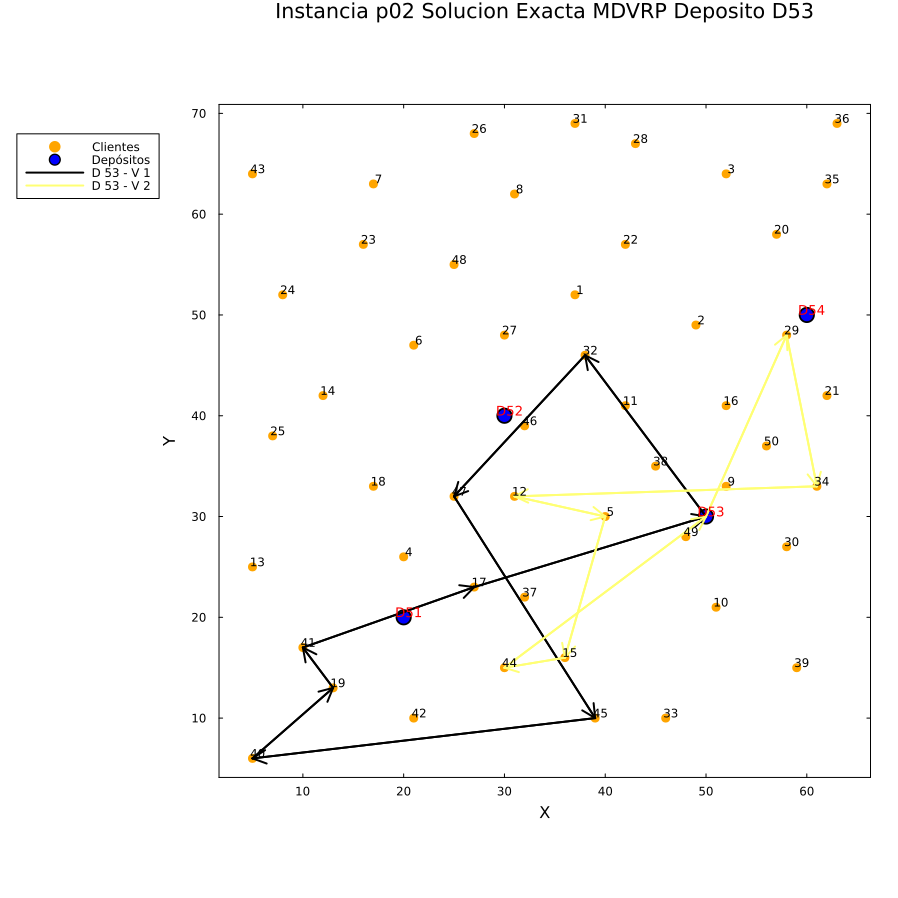

In [74]:
for d in keys(depositos)
     deposito_seleccionado = d  # 👈 elige el depósito
     
     p = graf_int(clientes, depositos, instancia, "Solucion Exacta MDVRP Deposito D$deposito_seleccionado")
     
     colores = distinguishable_colors(length(K))
     
     idx = 1
     
     for k in K
          
          arcos = [
               (i,j) for i in V, j in V
               if i != j &&
                    value(x[i,j,deposito_seleccionado,k]) > 1e-6
          ]
     
          if isempty(arcos)
               continue
          end
     
          primer_arco = true
     
          for (i,j) in arcos
     
               xi, yi = nodos[i]
               xj, yj = nodos[j]
     
               plot!(
                    p,
                    [xi, xj],
                    [yi, yj],
                    lw = 2,
                    color = colores[idx],
                    arrow = :arrow,
                    label = primer_arco ? "D $deposito_seleccionado - V $k" : false
               )
     
               primer_arco = false
          end
     
          idx += 1
     end
     
     plot!(
          p,
          framestyle = :box,
          legend = :outertopleft,
          left_margin = -10Plots.mm,
          right_margin = 5Plots.mm,
          top_margin = -10Plots.mm,
          bottom_margin = -10Plots.mm
     )

     display(p)

     ng = "Instancia_$(instancia)_Solucion_Exacta_MDVRP_Deposito_D$(deposito_seleccionado)"

     savefig(p, "$ruta/$ng.png")
end 

In [75]:
println("Rutas encontradas:\n")

for d in D
     println("===================================")
     println("DEPÓSITO $d")
     println("===================================\n")

     for k in K
          println("Vehículo $k:")

          # extraer arcos activos
          arcos = [(i,j) for i in V, j in V
                    if i != j && value(x[i,j,d,k]) > 0.5]

          if isempty(arcos)
               println("  (sin ruta)")
               continue
          end

          # reconstruir ruta
          ruta = Dict{Any, Any}()

          for (i,j) in arcos
               ruta[i] = j
          end

          # encontrar inicio (depósito)
          start = d

          visitados = Set()

          current = start
          print("  $current")

          while true
               if haskey(ruta, current) && !(current in visitados)
                    next = ruta[current]
                    print(" -> $next")
                    push!(visitados, current)
                    current = next
               else
                    break
               end
          end

          println("\n")
     end
end

Rutas encontradas:

DEPÓSITO 51

Vehículo 1:
  51 -> 37 -> 4 -> 23 -> 43 -> 31 -> 48 -> 46 -> 51

Vehículo 2:
  51 -> 13 -> 42 -> 49 -> 33 -> 51

DEPÓSITO 54

Vehículo 1:
  54 -> 1 -> 18 -> 27 -> 28 -> 8 -> 16 -> 21 -> 54

Vehículo 2:
  54 -> 50 -> 9 -> 11 -> 22 -> 35 -> 36 -> 54

DEPÓSITO 52

Vehículo 1:
  52 -> 25 -> 7 -> 6 -> 24 -> 14 -> 26 -> 52

Vehículo 2:
  52 -> 2 -> 3 -> 20 -> 30 -> 10 -> 39 -> 38 -> 52

DEPÓSITO 53

Vehículo 1:
  53 -> 32 -> 47 -> 45 -> 40 -> 19 -> 41 -> 17 -> 53

Vehículo 2:
  53 -> 29 -> 34 -> 12 -> 5 -> 15 -> 44 -> 53

